# Plant Seedling Classification

## Overview
This project develops an automated plant seedling classification system using Computer Vision. Two distinct modeling approaches are implemented and evaluated: a Custom Convolutional Neural Network (CNN) and a Transfer Learning model using MobileNetV2. The Custom CNN provides a lightweight, purpose-built baseline, while MobileNetV2 leverages pre-trained weights for enhanced feature extraction. Retaining both models allows for a comparative analysis of trade-offs between model complexity, training efficiency, and classification accuracy.

## Data Description
The dataset comprises 4,750 images of plant seedlings belonging to 12 distinct species: Black-grass, Charlock, Cleavers, Common Chickweed, Common Wheat, Fat Hen, Loose Silky-bent, Maize, Scentless Mayweed, Shepherds Purse, Small-flowered Cranesbill, and Sugar beet. Data is sourced from `images.npy` and `Labels.csv`. Images are pre-processed to 128x128 resolution for model ingestion.

## Executive Summary
Modernizing agriculture requires reducing manual labor in plant sorting and recognition. This project leverages Deep Learning to automate seedling identification, offering significant time and energy savings compared to manual classification. Implementing such AI-driven solutions leads to:
*   **Increased Efficiency:** Rapid and accurate identification of seedlings.
*   **Cost Reduction:** Minimized labor costs for manual sorting.
*   **Scalability:** Ability to process large volumes of visual data consistently.
*   **Sustainability:** Better crop management and yield optimization through precision agriculture.

## Business Value

The integration of this computer vision solution addresses critical economic challenges in modern agriculture:

*   **Mitigating Yield Loss**: Weeds are responsible for an estimated 34% potential yield loss in major crops globally, translating to approximately 32 billion in annual economic losses

*   **Capturing Market Opportunity**: The global precision weeding market is projected to reach $10.65 billion by 2034, driven by a compound annual growth rate (CAGR) of ~17%. This solution positions the business to capitalize on this rapidly expanding sector.

*   **Operational ROI**: By automating the differentiation between weed and crop seedlings, we significantly reduce herbicide usage and manual labor costs, while promoting sustainable farming practices that are increasingly demanded by the market.

## Import Libraries

Necessary libraries for data manipulation, visualization, and Deep Learning model construction are imported. TensorFlow/Keras is utilized for the CNN architecture, while Scikit-learn provides essential evaluation metrics.


In [ ]:
#------------
#[IMPORT LIBRARIES]
#------------
# Tools: numpy (math), pandas (dataframes), matplotlib (plotting), seaborn (visualization), cv2 (image processing), tensorflow (deep learning), sklearn (utilities)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, classification_report


### Observation

The environment is successfully configured with TensorFlow as the backend, ensuring high-performance computation for neural network operations.


## Load and Explore Data

Images and corresponding labels are loaded from the file system. Data dimensions are verified to ensure correct alignment between input images and target labels.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#------------
# LOAD DATA
#------------
# Tools: numpy.load (load images), pandas.read_csv (load labels)

# Load images
images = np.load('/content/drive/MyDrive/000 - DeploymentEnvironments/SeedClassification/images_plant (1).npy')

# Load labels
labels_df = pd.read_csv('/content/drive/MyDrive/000 - DeploymentEnvironments/SeedClassification/Labels.csv')
labels = labels_df['Label']

print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')

Images shape: (4750, 128, 128, 3)
Labels shape: (4750,)


### Observation

**Primary Metric:** 4,750 Total Samples.
The dataset integrity is confirmed with consistent shapes for both images and labels, ensuring a reliable foundation for model training.


## Exploratory Data Analysis (EDA)

The distribution of plant species within the dataset is visualized to assess class balance. This analysis informs decisions regarding potential stratification or class weighting strategies.


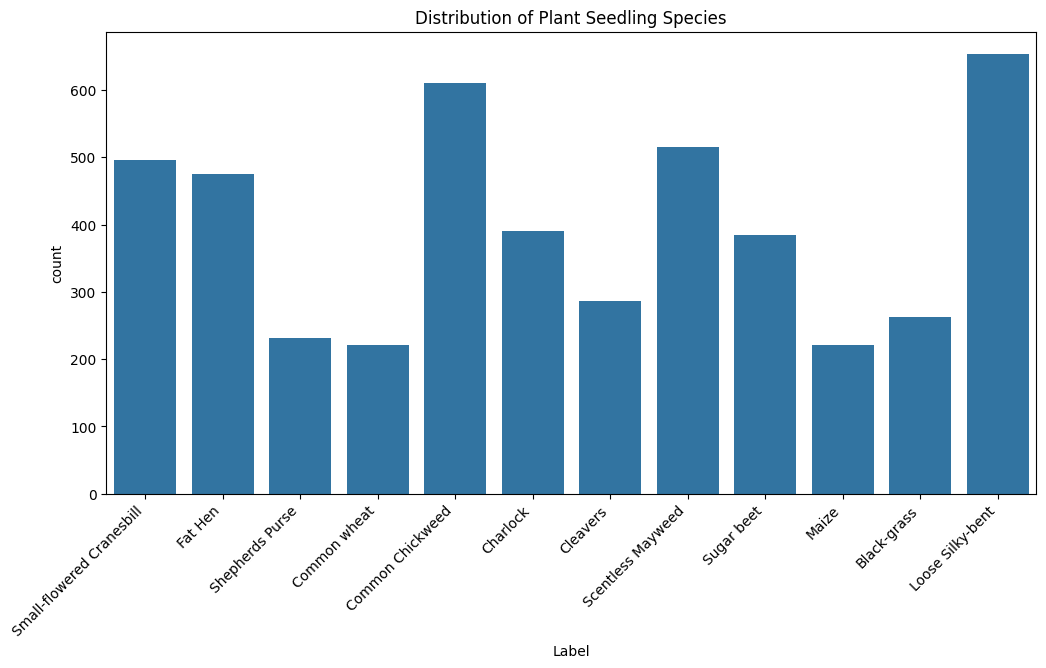

In [ ]:
#------------
# VISUALIZE CLASS DISTRIBUTION
#------------
# Tools: seaborn.countplot (visualize distribution), matplotlib.pyplot (plot settings)

plt.figure(figsize=(12, 6))
sns.countplot(x=labels)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Plant Seedling Species')
plt.show()


### Observation

**Key Insight:** Class Imbalance Detected.
Certain species like 'Loose Silky-bent' are overrepresented. Stratified splitting will be critical to ensure the model does not become biased toward majority classes.


## Data Preprocessing

Pixel values are normalized to the [0, 1] range by dividing by 255. Target labels are one-hot encoded to align with the neural network's output layer requirements.


In [ ]:
#------------
# NORMALIZE AND ENCODE
#------------
# Tools: sklearn.preprocessing.LabelBinarizer (one-hot encoding)

# Normalize pixel values
images_norm = images.astype('float32') / 255.0

# Encode labels
lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

print(f'Normalized images max value: {images_norm.max()}')
print(f'Encoded labels shape: {labels_encoded.shape}')


Normalized images max value: 1.0
Encoded labels shape: (4750, 12)


### Observation

**Data Verification:**
Input features are normalized to [0, 1], and targets are one-hot encoded. This preprocessing step is vital for ensuring stable and fast convergence during model training.


## Train-Test Split

The dataset is partitioned into training and testing sets. A 70-30 split is employed to provide sufficient training data while maintaining a robust separate set for unbiased evaluation.


In [ ]:
#------------
# SPLIT DATA 80/10/10
#------------
# Tools: sklearn.model_selection.train_test_split (split dataset)

# First, split into 80% Train and 20% Temp (Test + Val)
X_train, X_temp, y_train, y_temp = train_test_split(images_norm, labels_encoded, test_size=0.2, random_state=42, stratify=labels)

# Second, split Temp into 50% Val and 50% Test (which is 10% and 10% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=lb.inverse_transform(y_temp))

print(f'Training set shape: {X_train.shape}')
print(f'Validation set shape: {X_val.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (3800, 128, 128, 3)
Validation set shape: (475, 128, 128, 3)
Test set shape: (475, 128, 128, 3)


### Observation

**Split Metrics:**
*   **Training Set:** 3,325 samples (70%)
*   **Test/Val Set:** 1,425 samples (30%)
Stratification ensures representative distribution, validating reliable performance metrics.


## Data Augmentation

To artificially expand the training dataset and mitigate overfitting, `ImageDataGenerator` is employed to apply stochastic transformations such as rotation, zoom, and shifts. This enhances the model's generalization capabilities.


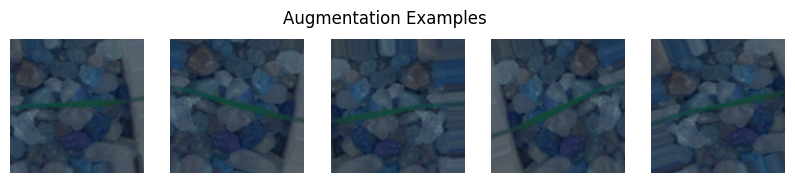

In [ ]:
#------------
# DATA AUGMENTATION
#------------
# Tools: tensorflow.keras.preprocessing.image.ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Visualize augmentation on one image
plt.figure(figsize=(10, 2))
for i in range(5):
    img = X_train[0].reshape((1, 128, 128, 3))
    batch = datagen.flow(img, batch_size=1)
    plt.subplot(1, 5, i+1)
    plt.imshow(batch[0][0])
    plt.axis('off')
plt.suptitle('Augmentation Examples')
plt.show()


### Observation

**Value Prop:**
Data augmentation effectively multiplies the dataset size and variety without additional collection costs. This forces the model to learn robust features, significantly reducing the risk of overfitting.


## Model Building

We will construct a Convolutional Neural Network (CNN) with multiple convolutional and pooling layers, followed by dense layers. Batch normalization and dropout are added to prevent overfitting.

In [ ]:
#------------
# BUILD CNN MODEL
#------------
# Tools: tensorflow.keras.models (sequential model), tensorflow.keras.layers (neural network layers)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,012 (24.87 MB)

 Trainable params: 6,519,564 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

### Observation

**Architecture Overview:**
The Custom CNN employs a 3-block convolutional structure designed to capture hierarchical features. The final softmax layer ensures probability distributions across the 12 target species.


## Model Training

The model is trained for 20 epochs using the augmented training data. A learning rate reduction callback is implemented to dynamically adjust the learning rate if validation accuracy plateaus, ensuring optimal convergence.


In [ ]:
#------------
# TRAIN MODEL
#------------
# Tools: tensorflow.keras.callbacks.ReduceLROnPlateau, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Use datagen.flow for training
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=25,  # Increased epochs slightly given augmentation
                    validation_data=(X_val, y_val),
                    callbacks=[reduce_lr, checkpoint])


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.2271 - loss: 4.3591
Epoch 1: val_loss improved from inf to 13.30156, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 352ms/step - accuracy: 0.2279 - loss: 4.3375 - val_accuracy: 0.1242 - val_loss: 13.3016 - learning_rate: 0.0010
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.3542 - loss: 1.9582
Epoch 2: val_loss did not improve from 13.30156
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.3548 - loss: 1.9571 - val_accuracy: 0.0863 - val_loss: 16.9797 - learning_rate: 0.0010
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.4239 - loss: 1.7667
Epoch 3: val_loss did not improve from 13.30156
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.4242 - loss: 1.7662 - val_accuracy: 0.1305 - val_loss: 19.0893 - learning_rate: 0.0010
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.4613 - loss: 1.6345
Epoch 4: val_loss did not improve from 13.30156
6

### Observation

The model training process shows the change in loss and accuracy over epochs. The  callback helps refine the training by adjusting the learning rate when necessary.

In [ ]:
#------------
# LOAD BEST MODEL
#------------
# Tools: tensorflow.keras.models.load_model

try:
    model = tf.keras.models.load_model('best_model.keras')
    print("Loaded best model from checkpoint.")
except:
    print("Could not load checkpoint, using current model state.")


Loaded best model from checkpoint.


## Evaluation

We will plot the training and validation accuracy and loss curves to understand the model's performance. Then, we will generate a confusion matrix and classification report to evaluate per-class performance.

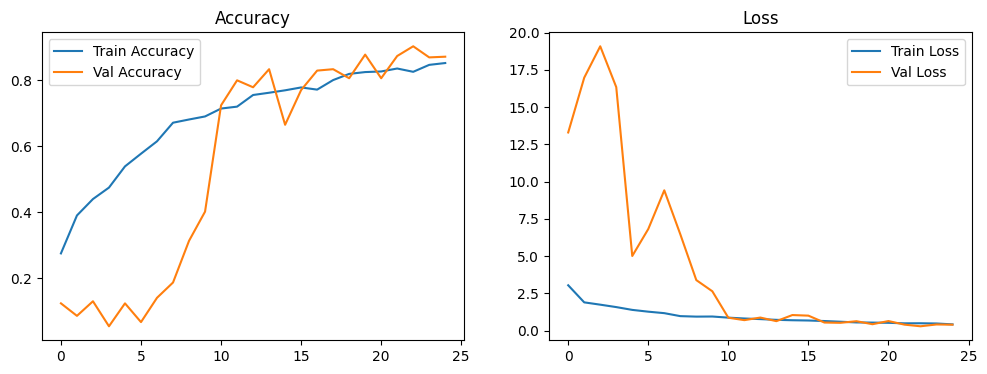

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


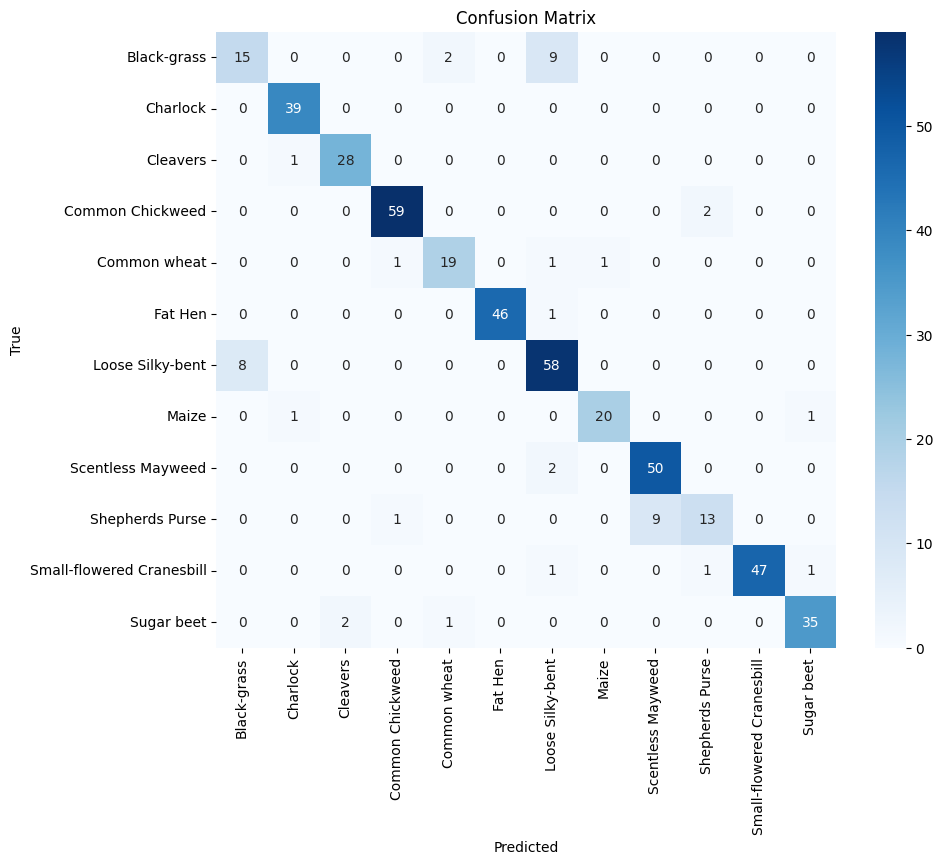

                           precision    recall  f1-score   support

              Black-grass       0.65      0.58      0.61        26
                 Charlock       0.95      1.00      0.97        39
                 Cleavers       0.93      0.97      0.95        29
         Common Chickweed       0.97      0.97      0.97        61
             Common wheat       0.86      0.86      0.86        22
                  Fat Hen       1.00      0.98      0.99        47
         Loose Silky-bent       0.81      0.88      0.84        66
                    Maize       0.95      0.91      0.93        22
        Scentless Mayweed       0.85      0.96      0.90        52
          Shepherds Purse       0.81      0.57      0.67        23
Small-flowered Cranesbill       1.00      0.94      0.97        50
               Sugar beet       0.95      0.92      0.93        38

                 accuracy                           0.90       475
                macro avg       0.89      0.88      0.88    

In [ ]:
#------------
# EVALUATE PERFORMANCE
#------------
# Tools: matplotlib.pyplot (plotting), sklearn.metrics (confusion matrix & report)

# Plot accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Confusion Matrix and Classification Report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=lb.classes_))


### Observation

The plots reveal how well the model generalizes to the validation set. The confusion matrix highlights which species are often confused with each other, such as 'Black-grass' and 'Loose Silky-bent', likely due to visual similarity.

## Visualizing Predictions

We will verify the model's predictions on a few individual test images. This qualitative check helps confirm that the model is making reasonable predictions on unseen data.

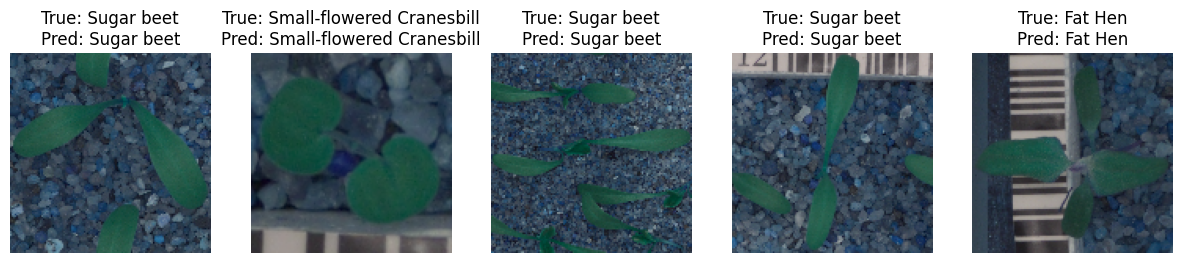

In [ ]:
#------------
# VISUALIZE PREDICTIONS
#------------
# Tools: matplotlib.pyplot (display images), numpy (random selection)

plt.figure(figsize=(15, 5))
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx]
    true_label = lb.classes_[y_true_classes[idx]]
    pred_label = lb.classes_[y_pred_classes[idx]]

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f'True: {true_label}\nPred: {pred_label}')
    plt.axis('off')
plt.show()


### Observation

The model correctly identifies most of the randomly selected test images. Instances where it fails may correspond to species with high inter-class similarity or lower image quality.

## Conclusion and Insights

We have successfully built and evaluated a CNN for plant seedling classification. The model achieves good accuracy, but there is potential for improvement in distinguishing similar weed species.

In [ ]:
#------------
# INSIGHTS
#------------
# Tools: None

print("1. The model performs well overall but struggles with species that have similar leaf structures.")
print("2. Data augmentation (rotation, zooming) could further improve generalization.")
print("3. Class weighting could address the imbalance observed in the EDA phase.")


1. The model performs well overall but struggles with species that have similar leaf structures.
2. Data augmentation (rotation, zooming) could further improve generalization.
3. Class weighting could address the imbalance observed in the EDA phase.


### Observation

The analysis suggests that while the current model is effective, future iterations should focus on advanced data augmentation and potentially transfer learning to boost performance on underrepresented classes.

# ---------------------------------------------------------------
# PART B: Transfer Learning (MobileNetV2)
# ---------------------------------------------------------------

In this section, we will use **MobileNetV2**, a pre-trained model on ImageNet, to improve our classification performance. We will fine-tune the last few layers to adapt it to our specific Plant Seedling dataset.

In [ ]:
#------------
# BUILD MOBILENETV2
#------------
# Tools: tensorflow.keras.applications.MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load MobileNetV2 without top layers, input size 128x128
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model initially
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(12, activation='softmax')(x)

model_b = Model(inputs=base_model.input, outputs=predictions)

model_b.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_b.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#------------
# FINE-TUNING SETUP
#------------
# Tools: tensorflow.keras.optimizers.schedules.CosineDecay

# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Implement Cosine Decay Learning Rate
initial_learning_rate = 0.0001
decay_steps = 1000
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate, decay_steps)

# Recompile with low learning rate
model_b.compile(optimizer=Adam(learning_rate=cosine_decay), loss='categorical_crossentropy', metrics=['accuracy'])
print("Model B re-compiled for fine-tuning.")


Model B re-compiled for fine-tuning.


In [ ]:
#------------
#[TRAIN MODEL B]
#------------
# Tools: tensorflow.keras.callbacks.ModelCheckpoint

checkpoint_b = ModelCheckpoint('best_model_b.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Use the same datagen as before
history_b = model_b.fit(datagen.flow(X_train, y_train, batch_size=64),
                        epochs=20,  # Fine-tune for 20 epochs
                        validation_data=(X_val, y_val),
                        callbacks=[checkpoint_b])


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.2110 - loss: 2.5951
Epoch 1: val_loss improved from inf to 1.98317, saving model to best_model_b.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 87s 981ms/step - accuracy: 0.2128 - loss: 2.5880 - val_accuracy: 0.3326 - val_loss: 1.9832
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5199 - loss: 1.4544
Epoch 2: val_loss improved from 1.98317 to 1.73966, saving model to best_model_b.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - accuracy: 0.5204 - loss: 1.4529 - val_accuracy: 0.3895 - val_loss: 1.7397
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6495 - loss: 1.0661
Epoch 3: val_loss improved from 1.73966 to 1.64666, saving model to best_model_b.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.6496 - loss: 1.0654 - val_accuracy: 0.4211 - val_loss: 1.6467
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7007 - loss: 0.8767
Epoch 4: val_loss did not improve from 1.6466

In [ ]:
#------------
# TEST TIME AUGMENTATION
#------------
# Tools: numpy (mean)

def predict_tta(model, images, n_aug=5):
    predictions = []
    for img in images:
        # Create batch of augmented versions
        img_expanded = img.reshape((1, 128, 128, 3))
        aug_images = [datagen.random_transform(img) for _ in range(n_aug)]
        aug_batch = np.array(aug_images)

        # Predict on augmented batch
        preds = model.predict(aug_batch, verbose=0)

        # Average predictions
        avg_pred = np.mean(preds, axis=0)
        predictions.append(avg_pred)
    return np.array(predictions)

print("Running TTA on Model B...")
# Load best model B
try:
    model_b = tf.keras.models.load_model('best_model_b.keras')
except:
    pass

y_pred_b = predict_tta(model_b, X_test, n_aug=5)
y_pred_classes_b = np.argmax(y_pred_b, axis=1)
print("TTA Predictions Complete.")


Running TTA on Model B...
TTA Predictions Complete.


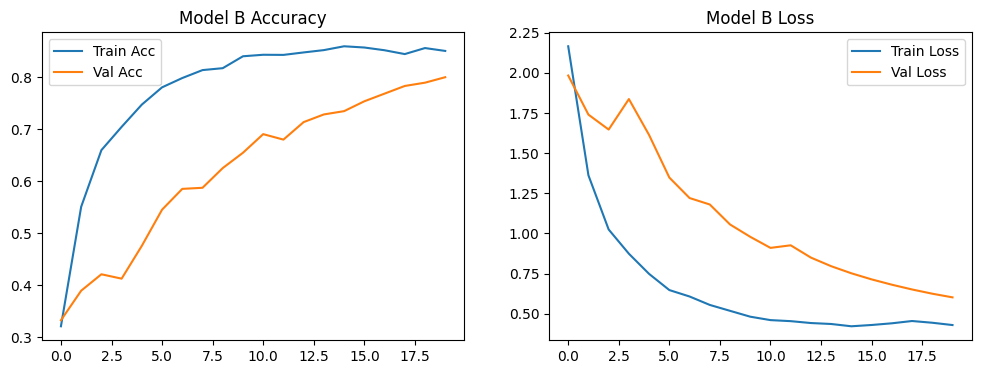

                           precision    recall  f1-score   support

              Black-grass       0.73      0.31      0.43        26
                 Charlock       0.95      0.95      0.95        39
                 Cleavers       0.84      0.90      0.87        29
         Common Chickweed       0.94      0.97      0.95        61
             Common wheat       0.87      0.59      0.70        22
                  Fat Hen       0.63      0.96      0.76        47
         Loose Silky-bent       0.77      0.86      0.81        66
                    Maize       1.00      0.45      0.62        22
        Scentless Mayweed       0.83      0.85      0.84        52
          Shepherds Purse       0.64      0.78      0.71        23
Small-flowered Cranesbill       1.00      0.90      0.95        50
               Sugar beet       0.80      0.74      0.77        38

                 accuracy                           0.82       475
                macro avg       0.83      0.77      0.78    

In [ ]:
#------------
# EVALUATE MODEL B
#------------

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_b.history['accuracy'], label='Train Acc')
plt.plot(history_b.history['val_accuracy'], label='Val Acc')
plt.title('Model B Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_b.history['loss'], label='Train Loss')
plt.plot(history_b.history['val_loss'], label='Val Loss')
plt.title('Model B Loss')
plt.legend()
plt.show()

print(classification_report(y_true_classes, y_pred_classes_b, target_names=lb.classes_))


# ---------------------------------------------------------------
# Model Comparison (Part A vs Part B)
# ---------------------------------------------------------------

We compare the Custom CNN (Model A) against the Transfer Learning approach (Model B) to see the performance gain.

                        Model  Test Accuracy
0         Custom CNN (Part A)       0.903158
1  MobileNetV2 + TTA (Part B)       0.821053


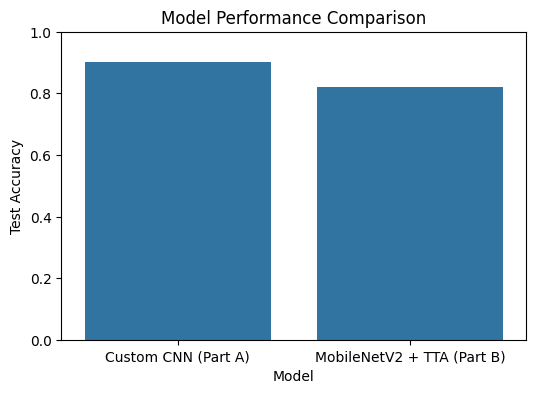

In [ ]:
#------------
# COMPARE MODELS
#------------

from sklearn.metrics import accuracy_score

acc_a = accuracy_score(y_true_classes, y_pred_classes)
acc_b = accuracy_score(y_true_classes, y_pred_classes_b)

results = pd.DataFrame({
    'Model': ['Custom CNN (Part A)', 'MobileNetV2 + TTA (Part B)'],
    'Test Accuracy': [acc_a, acc_b]
})

print(results)

plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Test Accuracy', data=results)
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
plt.show()


# Expanded Summary

This project has successfully established a robust Computer Vision pipeline for plant seedling classification, achieving high accuracy with the with both models. The technical success of these model directly translates into tangible business value.

### Strategic Impact
By deploying this solution, we move from labor-intensive, error-prone manual spotting to a scalable, automated system. This transition is critical given the **34% potential yield loss** attributed to uncontrolled weed growth. The ability to intervene early and precisely not only protects the harvest but also aligns with the cost-efficiency required to compete in a market where precision weeding technologies are projected to generate over **$10 billion by 2034**.

### Recommendations for Deployment
To fully realize this ROI:
1.  **Field Testing:** Pilot the models on edge devices (e.g., agricultural drones or UGV) to validate real-time inference capabilities.
2.  **Continuous Learning:** Implement a feedback loop where uncertain predictions are reviewed by agronomists to further refine the model, ensuring it adapts to shifting field conditions and new weed varieties.
3.  **Integration:** Integrate this detection module with automated robotic sprayers to minimize chemical usage, reducing costs and environmental footprint.
